# **Data Preprocessing for Agoda App Review**

### **Pra-pemrosesan Data (Data Preprocessing)**
Tahap pra-pemrosesan data merupakan langkah krusial untuk mentransformasi data mentah dari ulasan aplikasi Agoda menjadi format yang bersih dan konsisten. Rangkaian prosedur yang dilakukan adalah sebagai berikut:

1. **Penyaringan Bahasa (Language Filtering):** Menggunakan pustaka **`langid`** dengan teknik **komputasi paralel** untuk mengisolasi dataset agar hanya memuat ulasan berbahasa Inggris. Hal ini dilakukan untuk menjaga konsistensi linguistik dan menghindari *noise* dari bahasa lain.
2. **Ekstraksi Fitur Awal:** Mengimplementasikan **TextBlob** untuk mendapatkan nilai **polaritas** dan **subjektivitas** sebagai parameter awal dalam mengukur orientasi sentimen ulasan.
3. **Pembersihan Teks Dasar:** Meliputi **ekspansi singkatan (*contractions expansion*)** untuk mengembalikan kata seperti *"don't"* menjadi *"do not"*, serta **penyeragaman huruf kecil (*lowercasing*)** guna meminimalisasi variasi dimensi kosakata.
4. **Tokenisasi dan Lematisasi:** Teks dipecah menjadi unit terkecil (**token**) kemudian dilakukan **lematisasi** menggunakan **`WordNetLemmatizer`**. Metode ini dipilih dibanding *stemming* karena mampu mengembalikan kata ke bentuk dasar yang valid secara kamus, sehingga integritas makna tetap terjaga.
5. **Penghapusan Kata Tidak Bermakna (Stopword Removal):** Menghapus kata-kata umum yang tidak membawa bobot informasi. Namun, **kata negasi** tetap dipertahankan secara eksplisit agar orientasi sentimen asli tidak hilang.
6. **Eliminasi Tanda Baca dan Kata Langka:** Menghapus seluruh simbol tanda baca sisa serta kata-kata dengan frekuensi kemunculan sangat rendah (**di bawah 5 kali**). Langkah ini bertujuan untuk membuang *outlier* dan memastikan hanya fitur yang memiliki kekuatan statistik yang digunakan dalam analisis.

## **Libraries**

In [1]:
!pip install pandas
!pip install textblob
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install contractions
!pip install transformers
!pip install symspellpy
!pip install langid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=c1d343e8fa0bf627c495948c5c0295bc11f62ebe007fcbed95a95685bc5d028f
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [2]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.probability import FreqDist
import contractions
from transformers import BertTokenizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
import string
from symspellpy import SymSpell, Verbosity
from collections import Counter
import langid

# Apply the seaborn style before creating plots
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## **Load dataset**

In [3]:
#load data dari drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_agodarev = pd.read_csv('/content/drive/My Drive/PBA/rawdata.csv')
df_agodarev

/tmp/ipykernel_3292/3789933875.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_agodarev = pd.read_csv('/content/drive/My Drive/PBA/rawdata.csv')


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,de242464-90f8-4322-ab6f-7ed2194c969c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any incon...",2026-03-02 08:19:42,14.6.0
1,5a0fc31e-353a-48dd-a505-ee6e48738474,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,it's a great and very useful app honestly it o...,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience...,2026-03-02 05:07:34,14.6.0
2,2926363b-e0fc-4115-9585-67b931f6372c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Super good price!,5,0,14.6.0,2026-03-02 02:57:39,Thank you for sharing your positive experience...,2026-03-02 03:07:34,14.6.0
3,ac366bdb-052b-4eeb-917e-7662ebab3182,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Dear Sir/Madam, I made a booking yesterday at ...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the i...",2026-03-02 02:37:45,NaN
4,d008c6b3-a2e8-4f79-86a3-cb942622e6d8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,great help for booking room,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience...,2026-03-02 00:07:34,NaN
...,...,...,...,...,...,...,...,...,...,...,...
132870,3be631a1-2c8a-441b-b911-d8ed0e88e126,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Nicely done hotel booking app with some good r...,5,2,1.0,2011-08-08 19:32:32,NaN,NaN,1.0
132871,045a071c-5dfc-4a64-9157-a52a4193af1b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,5* not bad,5,0,1.0,2011-08-06 10:08:28,NaN,NaN,1.0
132872,e8b28b7a-bf23-4d0d-86a0-115ecb2385b1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Installed this last weekend (I was in Hua Hin,...",5,2,1.0,2011-08-04 04:09:01,NaN,NaN,1.0
132873,2ff4ffff-d47c-4397-bec1-ca7254b4134f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Can't search by hotel name (eg if u know the n...,1,1,1.0,2011-08-02 01:08:38,NaN,NaN,1.0


## **Tampilkan ringkasan informasi tentang DataFrame**

In [5]:
df_agodarev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132875 entries, 0 to 132874
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              132875 non-null  object
 1   userName              132875 non-null  object
 2   userImage             132875 non-null  object
 3   content               132754 non-null  object
 4   score                 132875 non-null  int64 
 5   thumbsUpCount         132875 non-null  int64 
 6   reviewCreatedVersion  118498 non-null  object
 7   at                    132875 non-null  object
 8   replyContent          55057 non-null   object
 9   repliedAt             55057 non-null   object
 10  appVersion            118498 non-null  object
dtypes: int64(2), object(9)
memory usage: 11.2+ MB


In [6]:
#Check number of reviews scores
df_agodarev['score'].value_counts()

,count
score,
5,83194
1,26022
4,17608
3,3758
2,2293


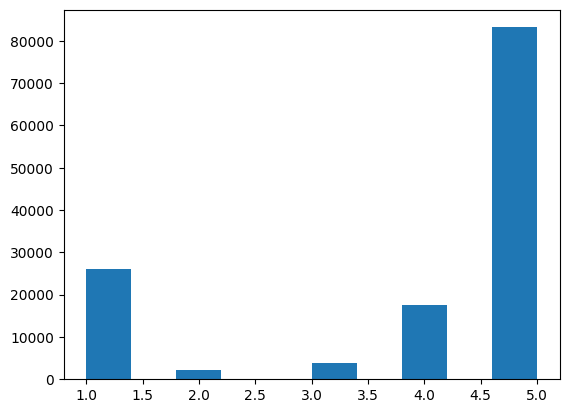

In [7]:
plt.hist(df_agodarev['score'])
plt.show()

In [8]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.4 MB/s eta 0:00:00


## **Mengubah tipe data 'at' dari Object menjadi Datetime**

Pada tahap ini, dilakukan transformasi tipe data pada atribut at (waktu penulisan ulasan) dari format teks (string) menjadi format standar datetime. Konversi ini esensial untuk memfasilitasi eksplorasi data berbasis waktu (time-series analysis), sehingga memungkinkan model atau analisis lanjutan untuk memetakan tren pergerakan sentimen pengguna pada periode tertentu. Pengecekan struktur dataset kemudian dilakukan guna memvalidasi bahwa perubahan tipe atribut tersebut telah berhasil dieksekusi dengan tepat.

In [9]:
df_agodarev['at'] = pd.to_datetime(df_agodarev['at'])
df_agodarev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132875 entries, 0 to 132874
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              132875 non-null  object        
 1   userName              132875 non-null  object        
 2   userImage             132875 non-null  object        
 3   content               132754 non-null  object        
 4   score                 132875 non-null  int64         
 5   thumbsUpCount         132875 non-null  int64         
 6   reviewCreatedVersion  118498 non-null  object        
 7   at                    132875 non-null  datetime64[ns]
 8   replyContent          55057 non-null   object        
 9   repliedAt             55057 non-null   object        
 10  appVersion            118498 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 11.2+ MB


## **Hapus Unnecessary dan Kolom Kosong**

Tahap selanjutnya melibatkan proses reduksi dimensi melalui eliminasi atribut-atribut metadata dan kolom perantara (intermediate) yang sudah tidak memiliki relevansi langsung terhadap ekstraksi sentimen. Bersamaan dengan itu, dilakukan pula pembersihan terhadap baris data yang teridentifikasi kosong (memiliki nilai null atau string kosong pasca-pembersihan teks). Tindakan kuratif ini sangat krusial untuk meminimalisasi noise, mengoptimalkan efisiensi alokasi memori komputasi, serta mencegah terjadinya anomali atau kegagalan matematis (error) saat dataset didistribusikan ke dalam arsitektur model pemelajaran mendalam (deep learning).

In [10]:
df_agodarev.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,121
score,0
thumbsUpCount,0
reviewCreatedVersion,14377
at,0
replyContent,77818
repliedAt,77818


In [11]:
df_agodarev = df_agodarev.drop(columns=['userName','userImage'])

In [12]:
df_agodarev.isnull().sum()

,0
reviewId,0
content,121
score,0
thumbsUpCount,0
reviewCreatedVersion,14377
at,0
replyContent,77818
repliedAt,77818
appVersion,14377


In [13]:
df_agodarev.tail()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
132870,3be631a1-2c8a-441b-b911-d8ed0e88e126,Nicely done hotel booking app with some good rates.,5,2,1.0,2011-08-08 19:32:32,NaN,NaN,1.0
132871,045a071c-5dfc-4a64-9157-a52a4193af1b,5* not bad,5,0,1.0,2011-08-06 10:08:28,NaN,NaN,1.0
132872,e8b28b7a-bf23-4d0d-86a0-115ecb2385b1,"Installed this last weekend (I was in Hua Hin, Thailand). Good selection of available hotels, map option handy for following easy route back to the hotel. Reasonably fast with a 3G connection and ...",5,2,1.0,2011-08-04 04:09:01,NaN,NaN,1.0
132873,2ff4ffff-d47c-4397-bec1-ca7254b4134f,Can't search by hotel name (eg if u know the name of hotel u want 2 book) & can't disable images so search is slow.,1,1,1.0,2011-08-02 01:08:38,NaN,NaN,1.0
132874,1422d6e6-a4b2-4481-b8ca-a6bf5f21bb5c,Buggy software. it picked today's date for my booking rather than the dates I chose. Rang agoda they said I can't amend bookings date Its the policy.,1,3,1.0,2011-07-29 03:58:12,NaN,NaN,1.0


In [14]:
# Hapus baris content yang kosong
df_agodarev = df_agodarev.dropna(subset=['content'])

# Menangani missing values
df_agodarev["replyContent"] = df_agodarev["replyContent"].fillna("No Reply")
df_agodarev["repliedAt"] = df_agodarev["repliedAt"].fillna("No Reply")

In [15]:
df_agodarev.isnull().sum()

,0
reviewId,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,14370
at,0
replyContent,0
repliedAt,0
appVersion,14370


In [16]:
df_agodarev

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,de242464-90f8-4322-ab6f-7ed2194c969c,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern through o...",2026-03-02 08:19:42,14.6.0
1,5a0fc31e-353a-48dd-a505-ee6e48738474,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience with us. Your feedback is much appreciated.\n\nWe're glad to know that you're happy and we are looking forward for your next journey with us! Have a ...,2026-03-02 05:07:34,14.6.0
2,2926363b-e0fc-4115-9585-67b931f6372c,Super good price!,5,0,14.6.0,2026-03-02 02:57:39,Thank you for sharing your positive experience with us. Your feedback is much appreciated.\n\nWe're glad to know that you're happy and we are looking forward for your next journey with us! Have a ...,2026-03-02 03:07:34,14.6.0
3,ac366bdb-052b-4eeb-917e-7662ebab3182,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern throu...",2026-03-02 02:37:45,NaN
4,d008c6b3-a2e8-4f79-86a3-cb942622e6d8,great help for booking room,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience with us. Your feedback is much appreciated.\n\nWe're glad to know that you're happy and we are looking forward for your next journey with us! Have a ...,2026-03-02 00:07:34,NaN
...,...,...,...,...,...,...,...,...,...
132870,3be631a1-2c8a-441b-b911-d8ed0e88e126,Nicely done hotel booking app with some good rates.,5,2,1.0,2011-08-08 19:32:32,No Reply,No Reply,1.0
132871,045a071c-5dfc-4a64-9157-a52a4193af1b,5* not bad,5,0,1.0,2011-08-06 10:08:28,No Reply,No Reply,1.0
132872,e8b28b7a-bf23-4d0d-86a0-115ecb2385b1,"Installed this last weekend (I was in Hua Hin, Thailand). Good selection of available hotels, map option handy for following easy route back to the hotel. Reasonably fast with a 3G connection and ...",5,2,1.0,2011-08-04 04:09:01,No Reply,No Reply,1.0
132873,2ff4ffff-d47c-4397-bec1-ca7254b4134f,Can't search by hotel name (eg if u know the name of hotel u want 2 book) & can't disable images so search is slow.,1,1,1.0,2011-08-02 01:08:38,No Reply,No Reply,1.0


## **Validasi Hanya Bahasa Inggris**

Tahap **penyaringan bahasa (*language filtering*)** dilakukan menggunakan pustaka **langid** untuk memastikan dataset hanya berisi **ulasan berbahasa Inggris ('en')**. Guna mempercepat pemrosesan data yang besar, deteksi ini dieksekusi menggunakan teknik **komputasi paralel (*multiprocessing*)**. Langkah ini esensial untuk **mencegah masuknya *noise*** dari bahasa asing, sehingga model dapat lebih fokus dan optimal dalam mempelajari pola sentimen.

In [17]:
import pandas as pd
import numpy as np
import langid
from multiprocessing import Pool, cpu_count

# 1. Fungsi deteksi menggunakan langid
def fast_langid(text):
    try:
        if isinstance(text, str) and len(text.strip()) > 5:
            # langid.classify mengembalikan tuple (bahasa, skor_kepercayaan)
            lang, _ = langid.classify(text[:100])
            return lang
        return "unknown"
    except:
        return "error"

# 2. Fungsi pembantu untuk pemrosesan paralel
def process_data_part(df_part):
    df_part['detected_lang'] = df_part['content'].apply(fast_langid)
    return df_part

def parallelize_dataframe(df, func):
    num_cores = cpu_count()
    # Membagi dataframe menjadi bagian-bagian sesuai jumlah core
    df_split = np.array_split(df, num_cores)

    with Pool(num_cores) as pool:
        df_result = pd.concat(pool.map(func, df_split))
    return df_result

# 3. Eksekusi
print(f"Sedang memproses {len(df_agodarev)} baris dengan Langid (Parallel Mode)...")

df_agodarev = parallelize_dataframe(df_agodarev, process_data_part)

# 4. Filter hanya ulasan Bahasa Inggris ('en')
df_agodarev = df_agodarev[df_agodarev['detected_lang'] == 'en'].reset_index(drop=True)

print(f"Selesai! Data Bahasa Inggris yang siap diproses: {len(df_agodarev)} baris.")
display(df_agodarev[['content', 'detected_lang']].head())

Sedang memproses 132754 baris dengan Langid (Parallel Mode)...


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Selesai! Data Bahasa Inggris yang siap diproses: 98781 baris.


,content,detected_lang
0,worst experience worst platform for hotel booking,en
1,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,en
2,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...",en
3,great help for booking room,en
4,"very poor experience, properties are not verified and not to trust on the pictures they're providing about the property .",en


## **Cek Polarity**

Tahap selanjutnya adalah **ekstraksi fitur sentimen** berbasis leksikon menggunakan pustaka **TextBlob**. Proses ini secara otomatis menghitung nilai **polaritas (*polarity*)** untuk mengidentifikasi kecenderungan arah ulasan (positif atau negatif), serta nilai **subjektivitas (*subjectivity*)** untuk mengukur seberapa besar teks tersebut memuat opini pribadi dibandingkan dengan fakta objektif. Fitur kuantitatif ini dapat dimanfaatkan sebagai **analisis sentimen pendahuluan** maupun sebagai fitur tambahan (*feature injection*) sebelum data diproses lebih lanjut menggunakan model *deep learning*.

In [18]:
df_agodarev['sentiment_polarity'] = df_agodarev['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_agodarev['sentiment_subjective'] = df_agodarev['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [19]:
#Tambahkan kolom polarity_rating dari review menjadi 3 labels: Pos, Negative Neutral
df_agodarev['sentiment_rating'] = df_agodarev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [20]:
df_agodarev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,worst experience worst platform for hotel booking,1,-1.000000,1.000000,Negative
1,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,5,0.441667,0.415000,Positive
2,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...",1,0.400000,0.825000,Negative
3,great help for booking room,5,0.800000,0.750000,Positive
4,"very poor experience, properties are not verified and not to trust on the pictures they're providing about the property .",1,-0.520000,0.780000,Negative
...,...,...,...,...,...
98776,Nicely done hotel booking app with some good rates.,5,0.650000,0.800000,Positive
98777,5* not bad,5,0.350000,0.666667,Positive
98778,"Installed this last weekend (I was in Hua Hin, Thailand). Good selection of available hotels, map option handy for following easy route back to the hotel. Reasonably fast with a 3G connection and ...",5,0.338235,0.579902,Positive
98779,Can't search by hotel name (eg if u know the name of hotel u want 2 book) & can't disable images so search is slow.,1,-0.300000,0.400000,Negative


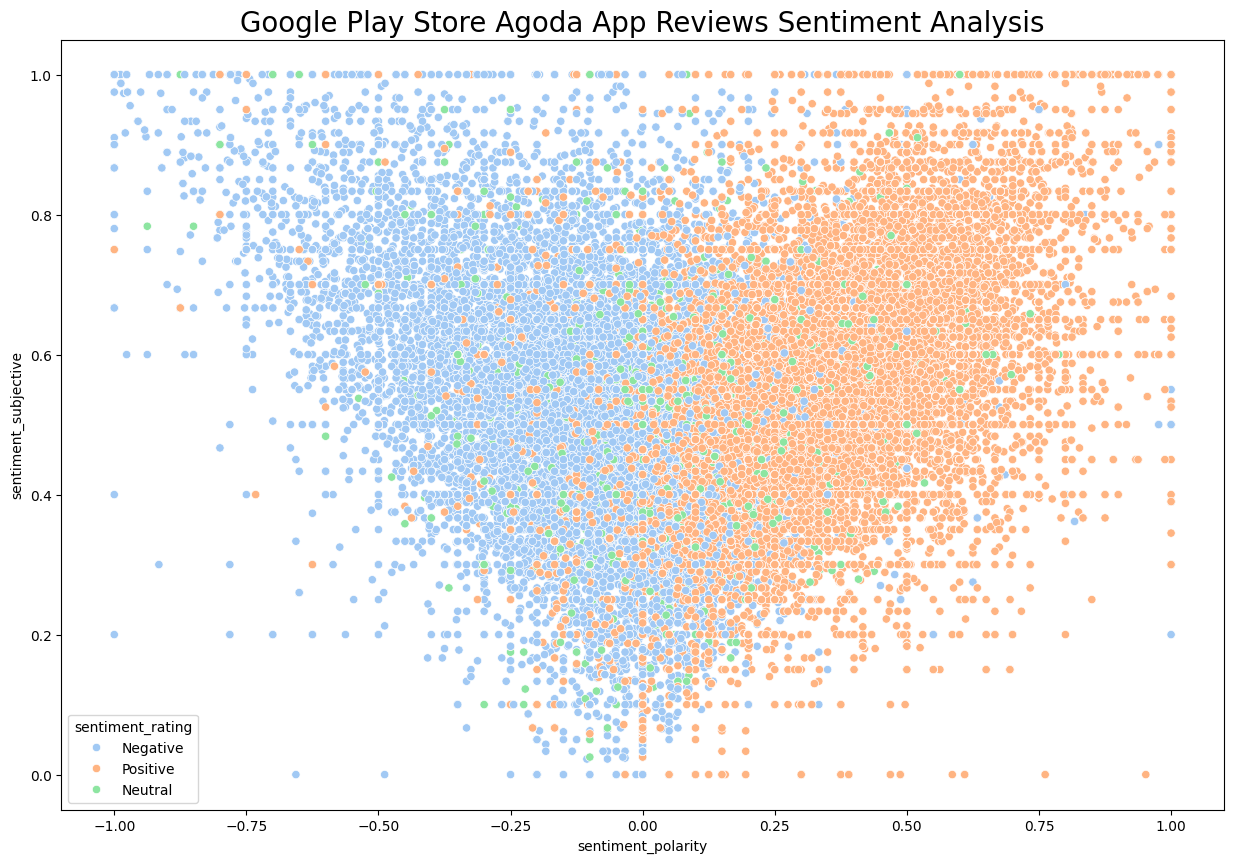

In [21]:
plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_agodarev['sentiment_polarity'], y=df_agodarev['sentiment_subjective'],
                hue=df_agodarev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Agoda App Reviews Sentiment Analysis", fontsize=20)
plt.show()

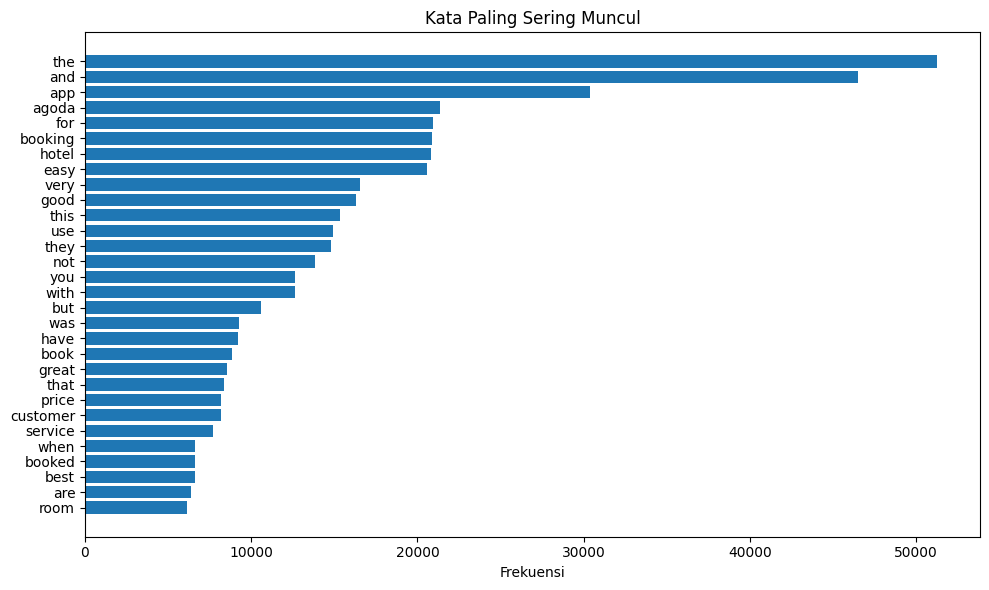

In [22]:
#Kata yang paling banyak muncul sebelum preprocessing
from collections import Counter
import re

all_text = " ".join(df_agodarev['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)

word_counts = Counter(words).most_common(30)

labels, values = zip(*word_counts)

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.title("Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Tahapan Preprocessing**

### **1. Expand Constractions**

Tahap pembersihan teks dengan **ekspansi singkatan (*contractions expansion*)** menggunakan pustaka **`contractions`**. Proses ini berfungsi untuk mengonversi bentuk singkatan informal bahasa Inggris (seperti *"don't"* atau *"can't"*) menjadi bentuk gramatikal utuhnya (*"do not"*, *"cannot"*). Langkah ini sangat krusial untuk **mempertahankan keberadaan kata negasi** yang sering kali melekat pada kata kerja, sehingga **makna sentimen asli** dari ulasan tetap utuh dan tidak terdistorsi saat diolah oleh model.

In [23]:
def expand_contractions(text):
    """Mengubah singkatan dalam teks menjadi bentuk lengkapnya."""
    return contractions.fix(text)

df_agodarev["content_expanded"] = df_agodarev["content"].apply(expand_contractions)
df_agodarev[["content", "content_expanded"]].head()

,content,content_expanded
0,worst experience worst platform for hotel booking,worst experience worst platform for hotel booking
1,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,it is a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃
2,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...","Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e..."
3,great help for booking room,great help for booking room
4,"very poor experience, properties are not verified and not to trust on the pictures they're providing about the property .","very poor experience, properties are not verified and not to trust on the pictures they are providing about the property ."


### **2. Tokenization**

Proses pra-pemrosesan dilanjutkan dengan **tokenisasi (*tokenization*)** menggunakan fungsi **`word_tokenize`**. Tahapan ini memecah kalimat utuh dari ulasan menjadi satuan unit terkecil berupa kata tunggal atau **token**. Pemecahan struktur teks ini merupakan fondasi esensial agar setiap kata dapat dianalisis, difilter, dan dibersihkan secara individual pada tahapan pemrosesan selanjutnya.

In [24]:
def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

#Terapkan tokenisasi pada kolom content_expanded
df_agodarev['tokenized_content'] = df_agodarev['content_expanded'].astype(str).apply(tokenize_text)

df_agodarev[['content', 'content_expanded', 'tokenized_content']].head()

,content,content_expanded,tokenized_content
0,worst experience worst platform for hotel booking,worst experience worst platform for hotel booking,"[worst, experience, worst, platform, for, hotel, booking]"
1,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,it is a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,"[it, is, a, great, and, very, useful, app, honestly, it, offers, some, awesome, deals, and, I, highly, recommend, it, ., Thanks, Agoda, 😃]"
2,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...","Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...","[Dear, Sir/Madam, ,, I, made, a, booking, yesterday, at, Hotel, from, 4, March, to, 5, March, ., I, have, booked, 2, rooms, and, the, payment, has, been, successfully, completed, ., However, ,, I,..."
3,great help for booking room,great help for booking room,"[great, help, for, booking, room]"
4,"very poor experience, properties are not verified and not to trust on the pictures they're providing about the property .","very poor experience, properties are not verified and not to trust on the pictures they are providing about the property .","[very, poor, experience, ,, properties, are, not, verified, and, not, to, trust, on, the, pictures, they, are, providing, about, the, property, .]"


### **3. Lowercasing**

Tahap pembersihan teks selanjutnya adalah **penyeragaman huruf kecil (*case folding/lowercasing*)**. Proses ini iteratif mengubah seluruh karakter kapital di dalam setiap token menjadi huruf kecil. Langkah ini sangat esensial untuk **menjaga konsistensi data** dan **mengurangi dimensi kosakata (*vocabulary size*)**, sehingga arsitektur *deep learning* (seperti BERT dan CNN) tidak mendeteksi kata yang sama dengan kapitalisasi berbeda (misalnya "Room" dan "room") sebagai dua entitas fitur yang terpisah.

In [25]:
def lower_tokens(tokens):
    return [t.lower() for t in tokens]

df_agodarev["tokens_lower"] = df_agodarev["tokenized_content"].apply(lower_tokens)

df_agodarev[["tokenized_content", "tokens_lower"]].head()

,tokenized_content,tokens_lower
0,"[worst, experience, worst, platform, for, hotel, booking]","[worst, experience, worst, platform, for, hotel, booking]"
1,"[it, is, a, great, and, very, useful, app, honestly, it, offers, some, awesome, deals, and, I, highly, recommend, it, ., Thanks, Agoda, 😃]","[it, is, a, great, and, very, useful, app, honestly, it, offers, some, awesome, deals, and, i, highly, recommend, it, ., thanks, agoda, 😃]"
2,"[Dear, Sir/Madam, ,, I, made, a, booking, yesterday, at, Hotel, from, 4, March, to, 5, March, ., I, have, booked, 2, rooms, and, the, payment, has, been, successfully, completed, ., However, ,, I,...","[dear, sir/madam, ,, i, made, a, booking, yesterday, at, hotel, from, 4, march, to, 5, march, ., i, have, booked, 2, rooms, and, the, payment, has, been, successfully, completed, ., however, ,, i,..."
3,"[great, help, for, booking, room]","[great, help, for, booking, room]"
4,"[very, poor, experience, ,, properties, are, not, verified, and, not, to, trust, on, the, pictures, they, are, providing, about, the, property, .]","[very, poor, experience, ,, properties, are, not, verified, and, not, to, trust, on, the, pictures, they, are, providing, about, the, property, .]"


### **4. Stopwords Removal**

Tahapan krusial dalam pra-pemrosesan ini adalah **penghapusan kata tidak bermakna (*stopword removal*)** menggunakan korpus dari pustaka **NLTK**. Pada tugas ini, daftar *stopwords* standar dimodifikasi secara spesifik. Pertama, **kata-kata negasi** (seperti *"not"*, *"no"*, *"never"*) secara eksplisit dipertahankan dari penghapusan, mengingat hilangnya negasi dapat mendistorsi orientasi sentimen secara fatal. Kedua, daftar tersebut diintegrasikan dengan ***custom stopwords* berbasis domain** (seperti *"agoda"*, *"hotel"*, *"app"*, beserta variasi tanda baca dan angka), guna mengeliminasi fitur redundan yang sering muncul namun tidak membawa bobot emosional. Sebagai langkah final, filter panjang token diterapkan untuk membuang **karakter dengan panjang kurang dari tiga huruf (*length < 3*)**. Modifikasi ini memastikan dataset yang dihasilkan sangat padat informasi dan terbebas dari *noise* kontekstual sebelum diumpankan ke dalam arsitektur model.

In [26]:
import nltk
from nltk.corpus import stopwords

# 1. Inisialisasi Stopwords Default
stop_words = set(stopwords.words("english"))

# 2. Pertahankan Kata Negasi
important_words = {"not", "no", "never", "nor", "n't"}

# 3. Daftar Stopwords Kustom Lengkap
custom_stopwords = [
    'app', 'hotel', 'booking', 'agoda', 'customer', 'book', 'booked', 'room', 'apps',
    'hotels', 'user', 'payment', 'application', 'property', 'stay', 'bookings', 'option',
    'reservation', 'flight', 'travel', 'place', 'date', 'options', 'company', 'trip',
    'account', 'owner', 'bank', 'phone', 'star', 'system', 'review', 'reviews', 'night',
    'use', 'get', 'using', 'pay', 'find', 'make', 'check', 'said', 'used', 'made',
    'call', 'email', 'go', 'tried', 'way', 'another', 'try', 'show', 'take', 'know', 'different',
    'told', 'received', 'change', 'see', 'provide', 'found', 'reached', 'able', 'keep',
    'called', 'due', 'showing', 'done', 'confirmed', 'every', 'say', 'asked', 'saying',
    'went', 'shows', 'reach', 'work', 'says', 'trying', 'getting', 'going', 'ask', 'new',
    'making', 'given', 'update', 'took', 'shown', 'gave', 'works', 'always', 'even',
    'time', 'one', 'got', 'also', 'please', 'still', 'first', 'ever', 'many', 'need',
    'much', 'want', 'would', 'back', 'give', 'last', 'already', 'days', 'times', 'lot',
    'full', 'far', 'could', 'since', 'well', 'via', 'day', 'hours', 'later', 'everything',
    'totally', 'two', 'anything', 'u', 'us', 'people', 'site', 'website', 'number',
    'amount', 'details', 'online', 'information', 'mobile', 'dan', 'di', 'saya', 'tidak',
    'aplikasi', 'yang', 'yg', 'sangat', 'ada', 'sudah', '&', '.', ' ', ',', '-', '!',
    '1', '2', '3', '4', '5', 'n', 'app.', 'agoda.', 'booking.', 'hotel.', 'use.', 'app,',
    'it.', 'service.', 'agoda,', 'hotel,', 'apps.', 'experience.', 'booking,', 'refund.',
    'use,', 'app!', 'price.', 'money.', 'hotels.', 'me.', 'again.', 'room.', 'good.',
    'time.', '..', '...'
]

# 4. Konstruksi Filter Final
# (Default dikurangi kata negasi) + Kustom
filtered_stop_words = (stop_words - important_words)
filtered_stop_words.update(custom_stopwords)

# 5. Fungsi Pembersihan (Input: tokens yang sudah lowercase)
def remove_stopwords(tokens):
    return [
        token.strip()
        for token in tokens
        if token not in filtered_stop_words and len(token) > 2
    ]

# 6. Terpakan pada kolom 'tokens_lower'
df_agodarev["tokens_cleaned"] = df_agodarev["tokens_lower"].apply(remove_stopwords)

# Verifikasi Hasil
display(df_agodarev[["tokens_lower", "tokens_cleaned"]].head())
print(f"Total Stopwords yang diterapkan: {len(filtered_stop_words)}")

,tokens_lower,tokens_cleaned
0,"[worst, experience, worst, platform, for, hotel, booking]","[worst, experience, worst, platform]"
1,"[it, is, a, great, and, very, useful, app, honestly, it, offers, some, awesome, deals, and, i, highly, recommend, it, ., thanks, agoda, 😃]","[great, useful, honestly, offers, awesome, deals, highly, recommend, thanks]"
2,"[dear, sir/madam, ,, i, made, a, booking, yesterday, at, hotel, from, 4, march, to, 5, march, ., i, have, booked, 2, rooms, and, the, payment, has, been, successfully, completed, ., however, ,, i,...","[dear, sir/madam, yesterday, march, march, rooms, successfully, completed, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, processed, plese,..."
3,"[great, help, for, booking, room]","[great, help]"
4,"[very, poor, experience, ,, properties, are, not, verified, and, not, to, trust, on, the, pictures, they, are, providing, about, the, property, .]","[poor, experience, properties, not, verified, not, trust, pictures, providing]"


Total Stopwords yang diterapkan: 379


Sebagai bentuk evaluasi terhadap efektivitas seluruh tahapan pra-pemrosesan teks yang telah dilakukan, diimplementasikan **analisis frekuensi kata (*Word Frequency Analysis*)**. Proses komputasi ini mengekstraksi dan menghitung kemunculan setiap token bersih menggunakan modul **`Counter`**, kemudian memvisualisasikan **20 kata yang paling sering muncul (*top 20 most frequent words*)** dalam bentuk **diagram batang horizontal (*horizontal bar chart*)**. Visualisasi ini berperan krusial untuk memvalidasi secara empiris bahwa korpus data teks kini telah terbebas dari *noise* maupun *stopwords*, serta membuktikan bahwa dataset akhir hanya didominasi oleh **fitur-fitur linguistik yang representatif dan bermakna** untuk mendukung tahap klasifikasi sentimen selanjutnya.

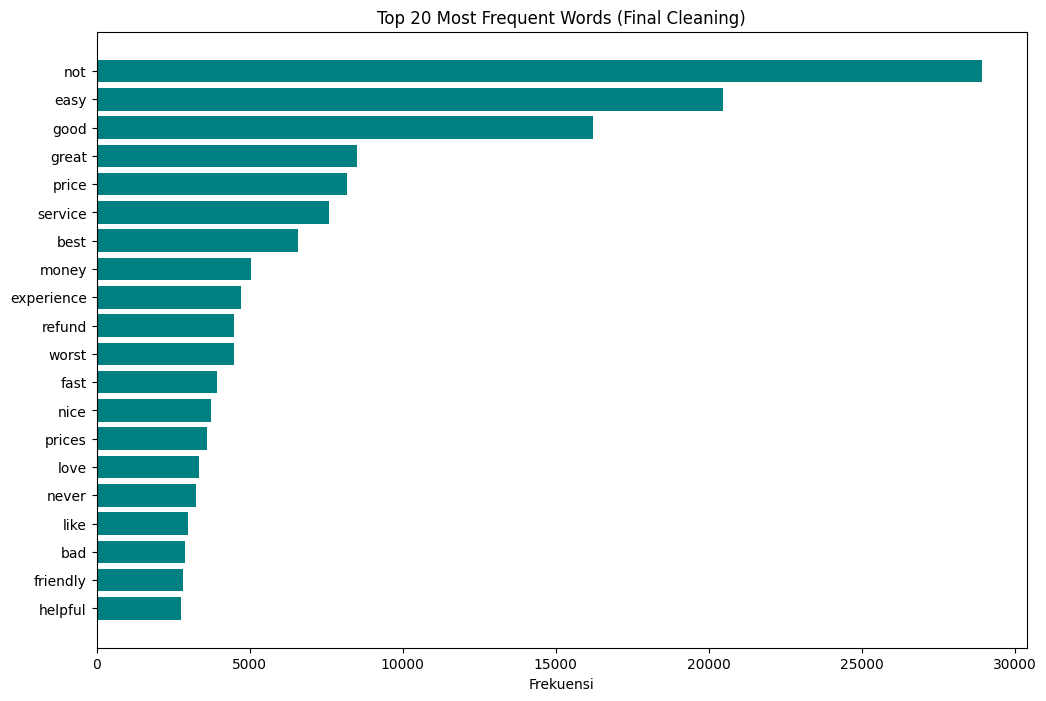

In [27]:
from collections import Counter
import matplotlib.pyplot as plt

# Ambil semua kata dari kolom yang baru dibersihkan
all_cleaned_tokens = [token for sublist in df_agodarev["tokens_cleaned"] for token in sublist]
final_word_counts = Counter(all_cleaned_tokens)
top_20_words = final_word_counts.most_common(20)

# Visualisasi
top_20_df = pd.DataFrame(top_20_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
plt.barh(top_20_df['Word'][::-1], top_20_df['Frequency'][::-1], color='teal')
plt.xlabel("Frekuensi")
plt.title("Top 20 Most Frequent Words (Final Cleaning)")
plt.show()

In [28]:
# Perbandingan jumlah token sebelum dan sesudah stopwords removal
df_agodarev["len_before"] = df_agodarev["tokens_lower"].apply(len)
df_agodarev["len_after"] = df_agodarev["tokens_cleaned"].apply(len)

total_before = df_agodarev["len_before"].sum()
total_after = df_agodarev["len_after"].sum()

# Membuat DataFrame perbandingan
comparison = pd.DataFrame({
    "category": ["Sebelum Stopword", "Sesudah Stopword"],
    "jumlah_token": [total_before, total_after]
})

# Menghitung persentase reduksi untuk informasi tambahan
reduction_percentage = ((total_before - total_after) / total_before) * 100
print(f"Total Reduksi Token: {reduction_percentage:.2f}%")

display(comparison)

Total Reduksi Token: 67.75%


,category,jumlah_token
0,Sebelum Stopword,1703409
1,Sesudah Stopword,549302


### **5. Lemmatization**

Tahap pra-pemrosesan dilanjutkan dengan **lematisasi (*lemmatization*)** menggunakan **WordNetLemmatizer**. Pada tugas ini, metode lematisasi dipilih alih-alih **stemming** karena lematisasi mampu mengembalikan kata ke bentuk dasar yang valid secara kamus, sehingga **menjaga integritas makna** teks. Hal ini berbeda dengan *stemming* yang sering kali memotong akhiran kata secara sembarangan hingga menghilangkan makna aslinya. Proses ini difokuskan pada **normalisasi kata kerja (`pos="v"`)** guna menyeragamkan berbagai bentuk waktu dan variasi infleksi, sehingga diperoleh **data yang lebih konsisten** untuk tahap analisis selanjutnya.

In [29]:
lemmatizer = WordNetLemmatizer()

# Fungsi Lematisasi (fokus pada verb/kata kerja)
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token, pos="v") for token in tokens]

# Terapkan pada kolom 'tokens_cleaned'
df_agodarev["tokens_lemmatized"] = df_agodarev["tokens_cleaned"].apply(lemmatize_tokens)

# Tampilkan hasil perbandingan
display(df_agodarev[["tokens_cleaned", "tokens_lemmatized"]].head())

,tokens_cleaned,tokens_lemmatized
0,"[worst, experience, worst, platform]","[worst, experience, worst, platform]"
1,"[great, useful, honestly, offers, awesome, deals, highly, recommend, thanks]","[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]"
2,"[dear, sir/madam, yesterday, march, march, rooms, successfully, completed, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, processed, plese,...","[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, plese, sen..."
3,"[great, help]","[great, help]"
4,"[poor, experience, properties, not, verified, not, trust, pictures, providing]","[poor, experience, properties, not, verify, not, trust, picture, provide]"


### **6. Punctuation Removal**

Tahap pra-pemrosesan teks dilanjutkan dengan **pembersihan tanda baca dan residu token (*punctuation and residual token removal*)**. Fungsi kustom diimplementasikan untuk menyaring (*filtering*) setiap elemen di dalam korpus agar terbebas dari sisa karakter tanda baca yang merujuk pada pustaka **`string.punctuation`**. Selain itu, tahap ini juga secara spesifik mengeliminasi **token tidak terdefinisi (*unknown token* atau `[UNK]`)** yang sering kali muncul sebagai anomali dari tahapan sebelumnya.

In [30]:
def clean_punctuation(tokens):
    """Menghapus tanda baca sisa dan token [UNK]"""
    return [token for token in tokens if token not in string.punctuation and token.lower() != "[unk]"]

df_agodarev["tokens_no_punctuation"] = df_agodarev["tokens_lemmatized"].apply(clean_punctuation)

display(df_agodarev[["tokens_lemmatized", "tokens_no_punctuation"]].head())

,tokens_lemmatized,tokens_no_punctuation
0,"[worst, experience, worst, platform]","[worst, experience, worst, platform]"
1,"[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]","[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]"
2,"[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, plese, sen...","[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, plese, sen..."
3,"[great, help]","[great, help]"
4,"[poor, experience, properties, not, verify, not, trust, picture, provide]","[poor, experience, properties, not, verify, not, trust, picture, provide]"


### **7. Spelling Correction**

Untuk menangani kesalahan pengetikan (typo) pada ulasan pengguna yang telah difilter, diimplementasikan algoritma **[SymSpell](https://github.com/wolfgarbe/SymSpell/blob/master/SymSpell/frequency_dictionary_en_82_765.txt)**. Dengan memanfaatkan frequency dictionary bahasa Inggris, kata-kata yang salah ketik akan dikoreksi ke bentuk yang paling mendekati berdasarkan jarak edit (edit distance), sehingga meningkatkan kualitas token sebelum masuk ke tahap pemodelan.

In [31]:
from symspellpy import SymSpell, Verbosity

# 1. Inisialisasi SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# 2. Muat Dictionary dari Google Drive
dictionary_path = "/content/drive/My Drive/PBA/frequency_dictionary_en_82_765.txt"
if not sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1):
    print("Gagal memuat dictionary. Pastikan file dictionary tersedia di path yang benar.")

# 3. Fungsi Koreksi Ejaan
def correct_spelling(tokens):
    corrected_tokens = []
    for token in tokens:
        # Mencari saran kata terdekat (Verbosity.CLOSEST)
        suggestion = sym_spell.lookup(token, Verbosity.CLOSEST, max_edit_distance=2)
        if suggestion:
            corrected_tokens.append(suggestion[0].term)
        else:
            corrected_tokens.append(token) # Gunakan kata asli jika tidak ditemukan saran
    return corrected_tokens

# 4. Terapkan pada kolom 'tokens_no_punctuation'
df_agodarev["tokens_spelling_corrected"] = df_agodarev["tokens_no_punctuation"].apply(correct_spelling)

# 5. Tampilkan baris yang mengalami perubahan untuk verifikasi
df_changes = df_agodarev[df_agodarev["tokens_no_punctuation"].astype(str) != df_agodarev["tokens_spelling_corrected"].astype(str)]

print(f"Ditemukan {len(df_changes)} ulasan yang mengalami koreksi ejaan.")
display(df_changes[["tokens_no_punctuation", "tokens_spelling_corrected"]].head())

Ditemukan 18194 ulasan yang mengalami koreksi ejaan.


,tokens_no_punctuation,tokens_spelling_corrected
2,"[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, plese, sen...","[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, please, se..."
7,"[significantly, lower, rate, inform, internal, issue, not, honor, market, price, double, although, free, cancellation, process, compensation, offer, despite, error, acknowledge, side, experience, ...","[significantly, lower, rate, inform, internal, issue, not, honor, market, price, double, although, free, cancellation, process, compensation, offer, despite, error, acknowledge, side, experience, ..."
17,"[zio, not, support]","[zip, not, support]"
21,"[lot, fake, register, gimik, low, price]","[lot, fake, register, limit, low, price]"
22,"[never, refund, take, upto, months, not, accept, offer]","[never, refund, take, unto, months, not, accept, offer]"


## **8. Rare Words Removal**

Tahap pra-pemrosesan selanjutnya dengan **eliminasi kata langka (*rare words removal*)** menggunakan pendekatan frekuensi berbasis ambang batas (*threshold*). Kata-kata unik yang memiliki frekuensi kemunculan sangat rendah (dalam penelitian ini kurang dari lima kali) diidentifikasi menggunakan **`Counter`** dan dihapus dari korpus. Penghapusan ini bertujuan untuk **mengurangi noise** dan membuang elemen data yang tidak memiliki kekuatan statistik yang cukup untuk mewakili pola sentimen secara umum. Dengan mengeleminasi kata-kata yang bersifat *outlier* atau spesifik hanya pada satu ulasan, diperoleh **dataset yang lebih padat dan representatif** guna meningkatkan akurasi hasil analisis pada tahap berikutnya.

In [32]:
from collections import Counter

# 1. Menghitung frekuensi kata dari hasil koreksi ejaan
word_counts = Counter(word for tokens in df_agodarev["tokens_spelling_corrected"] for word in tokens)

# 2. Menentukan threshold (kata muncul kurang dari 5 kali akan dihapus)
rare_threshold = 5
rare_words = {word for word, count in word_counts.items() if count < rare_threshold}

# 3. Fungsi untuk menghapus rare words dari token
def remove_rare_words(tokens):
    return [word for word in tokens if word not in rare_words]

# 4. Terapkan pada kolom 'tokens_spelling_corrected'
df_agodarev["tokens_rare_removed"] = df_agodarev["tokens_spelling_corrected"].apply(remove_rare_words)

# 5. Tampilkan baris yang mengalami perubahan untuk verifikasi
df_rare_changes = df_agodarev[df_agodarev["tokens_spelling_corrected"].astype(str) != df_agodarev["tokens_rare_removed"].astype(str)]

print(f"Jumlah kata unik yang dianggap langka: {len(rare_words)}")
print(f"Jumlah ulasan yang terdampak pembersihan: {len(df_rare_changes)}")
display(df_rare_changes[["tokens_spelling_corrected", "tokens_rare_removed"]].head())

Jumlah kata unik yang dianggap langka: 13450
Jumlah ulasan yang terdampak pembersihan: 11831


,tokens_spelling_corrected,tokens_rare_removed
2,"[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, please, se...","[dear, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, please, send, mail, c..."
5,"[save, credit, card, mistake, delete, service, unable/unwilling, help]","[save, credit, card, mistake, delete, service, help]"
7,"[significantly, lower, rate, inform, internal, issue, not, honor, market, price, double, although, free, cancellation, process, compensation, offer, despite, error, acknowledge, side, experience, ...","[significantly, lower, rate, inform, internal, issue, not, honor, market, price, double, although, free, cancellation, process, compensation, offer, despite, error, acknowledge, side, experience, ..."
19,"[today, cancel, today, refund, process, create, within, today, not, refund, immediately, request, not, site.we, sit, management, think, issue]","[today, cancel, today, refund, process, create, within, today, not, refund, immediately, request, not, sit, management, think, issue]"
33,"[write, formally, complain, platform, today, coimbatore, clear, mention, specific, checking, usage, time, restrictions, however, inform, available, 12:00, 11:00, condition, not, clearly, state, pr...","[write, complain, platform, today, coimbatore, clear, mention, specific, checking, usage, time, restrictions, however, inform, available, condition, not, clearly, state, process, refuse, expect, s..."


Selanjutnya, saya memutuskan untuk **tidak melakukan Common Words Removal**. Keputusan untuk tidak menerapkan tahapan Common Words Filter berbasis POS-tagging diambil guna menjaga integritas konteks dan makna semantik pada ulasan, terutama untuk mempertahankan kata-kata negasi seperti "not" yang sangat krusial bagi akurasi analisis sentimen.

### **9. Delete Empty Rows**

Setelah melewati berbagai tahap pembersihan, ada kemungkinan beberapa ulasan menjadi kosong karena seluruh katanya tergolong sebagai stopwords atau rare words. Menghapus baris kosong ini sangat penting agar model tidak mengalami gangguan teknis (seperti nilai null atau error dimensi) saat proses ekstraksi fitur, sehingga integritas data tetap terjaga untuk hasil analisis yang lebih valid.

In [33]:
# 1. Cek jumlah baris yang memiliki token kosong setelah preprocessing
df_empty = df_agodarev[df_agodarev["tokens_rare_removed"].apply(lambda x: len(x) == 0)]
print(f"Jumlah baris kosong ditemukan: {len(df_empty)}")

# 2. Hapus baris yang kosong dari dataframe utama
df_agodarev = df_agodarev[df_agodarev["tokens_rare_removed"].apply(lambda x: len(x) > 0)].copy()

# 3. Tampilkan jumlah ulasan final setelah penghapusan
print(f"Jumlah ulasan setelah menghapus baris kosong: {len(df_agodarev)}")

# Verifikasi hasil akhir
display(df_agodarev[["content", "tokens_rare_removed"]].head())

Jumlah baris kosong ditemukan: 1097
Jumlah ulasan setelah menghapus baris kosong: 97684


,content,tokens_rare_removed
0,worst experience worst platform for hotel booking,"[worst, experience, worst, platform]"
1,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,"[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]"
2,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...","[dear, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, please, send, mail, c..."
3,great help for booking room,"[great, help]"
4,"very poor experience, properties are not verified and not to trust on the pictures they're providing about the property .","[poor, experience, properties, not, verify, not, trust, picture, provide]"


## **Pengecekan setelah Preprocessing**

In [34]:
df_agodarev

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,detected_lang,...,content_expanded,tokenized_content,tokens_lower,tokens_cleaned,len_before,len_after,tokens_lemmatized,tokens_no_punctuation,tokens_spelling_corrected,tokens_rare_removed
0,de242464-90f8-4322-ab6f-7ed2194c969c,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern through o...",2026-03-02 08:19:42,14.6.0,en,...,worst experience worst platform for hotel booking,"[worst, experience, worst, platform, for, hotel, booking]","[worst, experience, worst, platform, for, hotel, booking]","[worst, experience, worst, platform]",7,4,"[worst, experience, worst, platform]","[worst, experience, worst, platform]","[worst, experience, worst, platform]","[worst, experience, worst, platform]"
1,5a0fc31e-353a-48dd-a505-ee6e48738474,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience with us. Your feedback is much appreciated.\n\nWe're glad to know that you're happy and we are looking forward for your next journey with us! Have a ...,2026-03-02 05:07:34,14.6.0,en,...,it is a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,"[it, is, a, great, and, very, useful, app, honestly, it, offers, some, awesome, deals, and, I, highly, recommend, it, ., Thanks, Agoda, 😃]","[it, is, a, great, and, very, useful, app, honestly, it, offers, some, awesome, deals, and, i, highly, recommend, it, ., thanks, agoda, 😃]","[great, useful, honestly, offers, awesome, deals, highly, recommend, thanks]",23,9,"[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]","[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]","[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]","[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]"
2,ac366bdb-052b-4eeb-917e-7662ebab3182,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern throu...",2026-03-02 02:37:45,NaN,en,...,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...","[Dear, Sir/Madam, ,, I, made, a, booking, yesterday, at, Hotel, from, 4, March, to, 5, March, ., I, have, booked, 2, rooms, and, the, payment, has, been, successfully, completed, ., However, ,, I,...","[dear, sir/madam, ,, i, made, a, booking, yesterday, at, hotel, from, 4, march, to, 5, march, ., i, have, booked, 2, rooms, and, the, payment, has, been, successfully, completed, ., however, ,, i,...","[dear, sir/madam, yesterday, march, march, rooms, successfully, completed, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, processed, plese,...",79,24,"[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, plese, sen...","[dear, sir/madam, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, plese, sen...","[dear, sir/madam, yesterday, march, march, room, successfully, comple

In [35]:
# 1. Menggabungkan kembali token menjadi kalimat utuh (String)
# Simpan hanya konten yang telah dibersihkan ke dalam 'content_cleaned'
df_agodarev["content_cleaned"] = df_agodarev["tokens_rare_removed"].apply(lambda x: " ".join(x))

# 2. Verifikasi hasil akhir perbandingan
print(f"Total data final yang siap digunakan: {len(df_agodarev)} baris.")

# Cek hasil dari teks asli, token, sampai hasil bersihnya
display(df_agodarev[['content', 'tokens_rare_removed', 'content_cleaned']].head())

Total data final yang siap digunakan: 97684 baris.


,content,tokens_rare_removed,content_cleaned
0,worst experience worst platform for hotel booking,"[worst, experience, worst, platform]",worst experience worst platform
1,it's a great and very useful app honestly it offers some awesome deals and I highly recommend it. Thanks Agoda 😃,"[great, useful, honestly, offer, awesome, deal, highly, recommend, thank]",great useful honestly offer awesome deal highly recommend thank
2,"Dear Sir/Madam, I made a booking yesterday at Hotel from 4 March to 5 March . I have booked 2 rooms and the payment has been successfully completed. However, I have not received any confirmation e...","[dear, yesterday, march, march, room, successfully, complete, however, not, confirmation, yet, additionally, unable, section, kindly, confirm, whether, successfully, process, please, send, mail, c...",dear yesterday march march room successfully complete however not confirmation yet additionally unable section kindly confirm whether successfully process please send mail confirmation
3,great help for booking room,"[great, help]",great help
4,"very poor experience, properties are not verified and not to trust on the pictures they're providing about the property .","[poor, experience, properties, not, verify, not, trust, picture, provide]",poor experience properties not verify not trust picture provide


In [36]:
df_cleaned = df_agodarev.copy()

In [37]:
df_cleaned = df_cleaned.drop(columns=[
    'content',
    'sentiment_polarity',
    'sentiment_subjective',
    'sentiment_rating',
    'content_expanded',
    'tokens_cleaned',
    'tokenized_content',
    'tokens_lower',
    'tokens_lemmatized',
    'tokens_no_punctuation',
    'tokens_spelling_corrected',
    'tokens_rare_removed'
])

# Cek hasil akhir
display(df_cleaned.head())

,reviewId,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,detected_lang,len_before,len_after,content_cleaned
0,de242464-90f8-4322-ab6f-7ed2194c969c,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern through o...",2026-03-02 08:19:42,14.6.0,en,7,4,worst experience worst platform
1,5a0fc31e-353a-48dd-a505-ee6e48738474,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience with us. Your feedback is much appreciated.\n\nWe're glad to know that you're happy and we are looking forward for your next journey with us! Have a ...,2026-03-02 05:07:34,14.6.0,en,23,9,great useful honestly offer awesome deal highly recommend thank
2,ac366bdb-052b-4eeb-917e-7662ebab3182,1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern throu...",2026-03-02 02:37:45,NaN,en,79,24,dear yesterday march march room successfully complete however not confirmation yet additionally unable section kindly confirm whether successfully process please send mail confirmation
3,d008c6b3-a2e8-4f79-86a3-cb942622e6d8,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience with us. Your feedback is much appreciated.\n\nWe're glad to know that you're happy and we are looking forward for your next journey with us! Have a ...,2026-03-02 00:07:34,NaN,en,5,2,great help
4,c070f35e-7d25-4831-a113-483aadecb902,1,0,14.6.0,2026-03-01 15:15:06,"Hi Nikhil Singh, we apologize for the inconvenience caused. We always strive to provide the best experience for our customers. Please share your booking ID, email address, and concern through priv...",2026-03-01 16:04:02,14.6.0,en,22,9,poor experience properties not verify not trust picture provide


In [38]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97684 entries, 0 to 98780
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              97684 non-null  object        
 1   score                 97684 non-null  int64         
 2   thumbsUpCount         97684 non-null  int64         
 3   reviewCreatedVersion  87303 non-null  object        
 4   at                    97684 non-null  datetime64[ns]
 5   replyContent          97684 non-null  object        
 6   repliedAt             97684 non-null  object        
 7   appVersion            87303 non-null  object        
 8   detected_lang         97684 non-null  object        
 9   len_before            97684 non-null  int64         
 10  len_after             97684 non-null  int64         
 11  content_cleaned       97684 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 9.7+ MB


In [39]:
# Handle None values in 'content' column by replacing them with empty strings
df_cleaned['sentiment_polarity'] = df_cleaned['content_cleaned'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_cleaned['sentiment_subjective'] = df_cleaned['content_cleaned'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [40]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_cleaned['sentiment_rating'] = df_cleaned['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [41]:
df_cleaned.loc[:,["content_cleaned","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content_cleaned,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,worst experience worst platform,1,-1.000000,1.000000,Negative
1,great useful honestly offer awesome deal highly recommend thank,5,0.572000,0.638000,Positive
2,dear yesterday march march room successfully complete however not confirmation yet additionally unable section kindly confirm whether successfully process please send mail confirmation,1,0.237500,0.687500,Negative
3,great help,5,0.800000,0.750000,Positive
4,poor experience properties not verify not trust picture provide,1,-0.400000,0.600000,Negative
...,...,...,...,...,...
98776,nicely good rat,5,0.700000,0.600000,Positive
98777,not bad,5,0.350000,0.666667,Positive
98778,instal weekend hub thailand good selection available map handy follow easy route reasonably fast connection quick skip image pretty easy love present confirmation front desk not ability sort price...,5,0.413636,0.624242,Positive
98779,not search name name not disable image search slow,1,-0.300000,0.400000,Negative


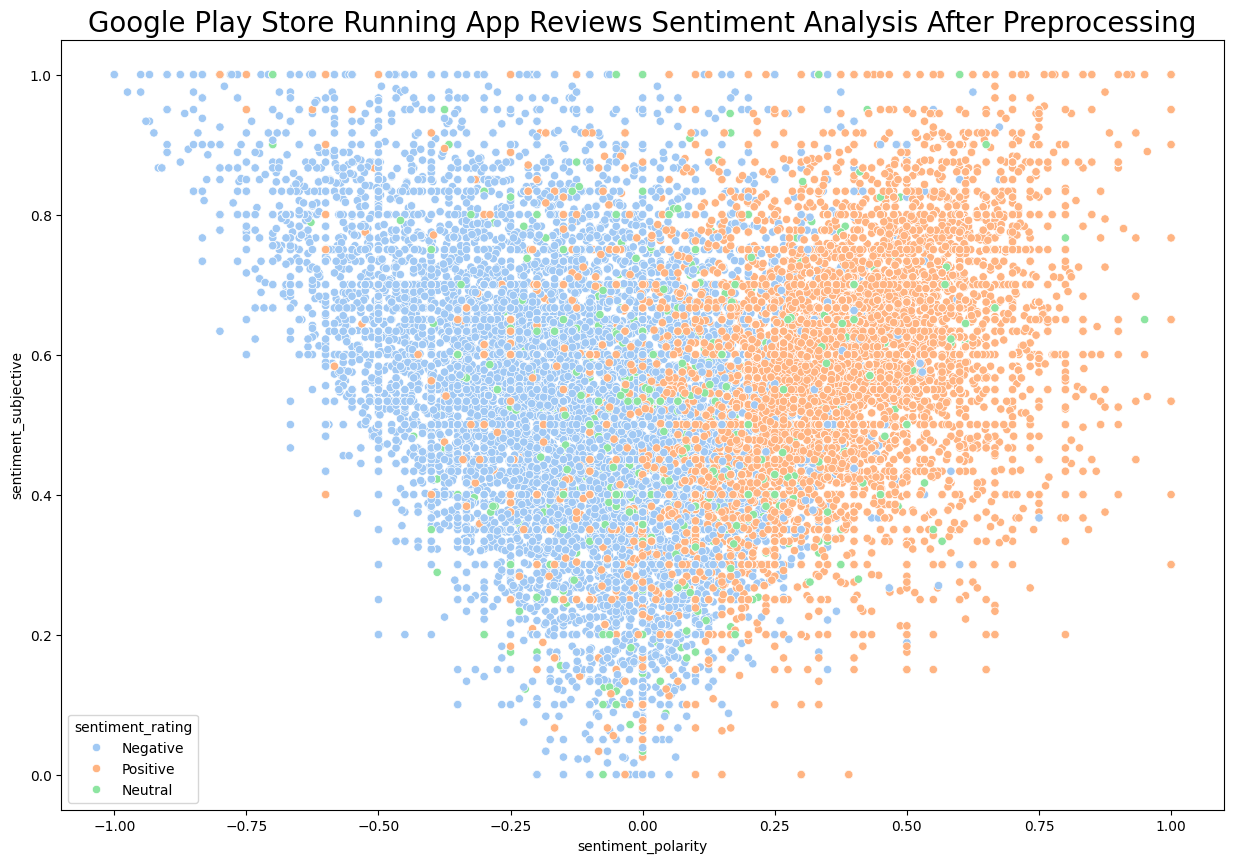

In [42]:
plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_cleaned['sentiment_polarity'], y=df_cleaned['sentiment_subjective'],
                hue=df_cleaned['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Running App Reviews Sentiment Analysis After Preprocessing", fontsize=20)
plt.show()

Untuk memvalidasi efektivitas tahapan pra-pemrosesan, dilakukan analisis frekuensi kata (Word Frequency Analysis) sebelum dan sesudah data dibersihkan. Visualisasi ini membuktikan bahwa kata-kata umum (stopwords) dan tanda baca yang sebelumnya mendominasi telah berhasil dieliminasi, sehingga menyisakan kata-kata yang lebih bermakna dan relevan untuk analisis sentimen.

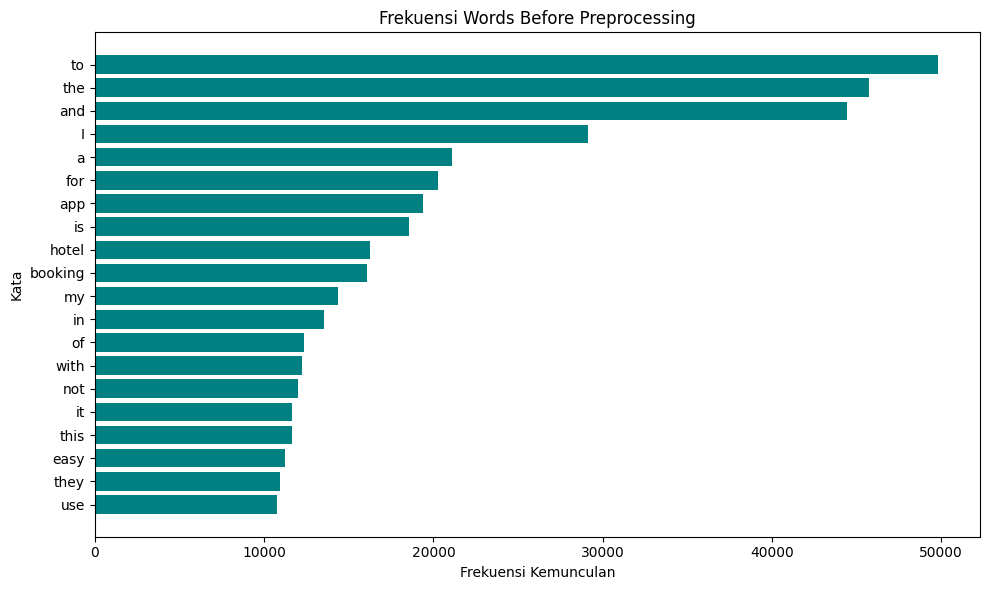

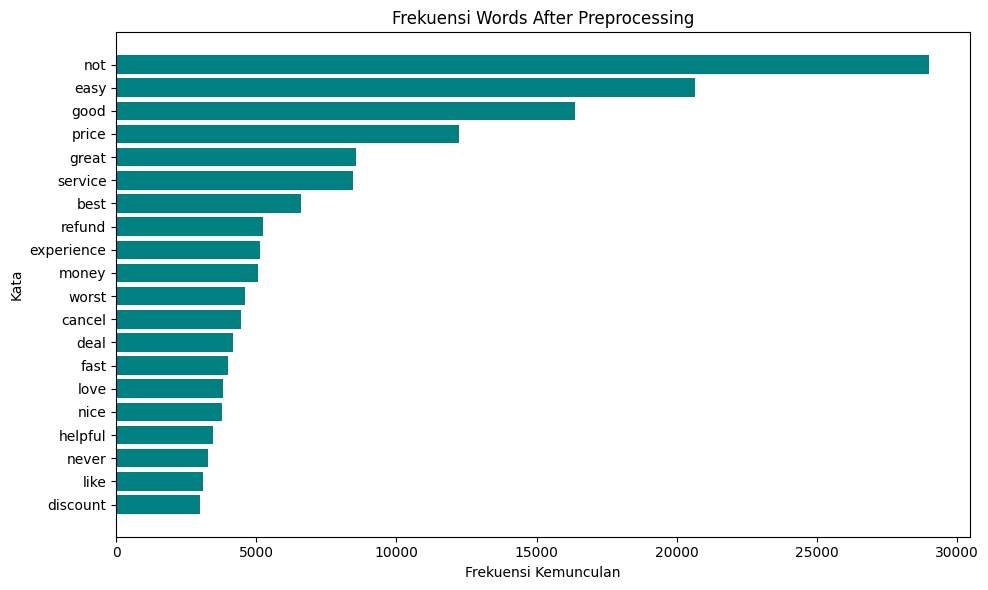

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Definisikan fungsi freq_words
def freq_words(text_series, title):
    # dropna() untuk mencegah error jika ada baris yang kosong (NaN)
    all_words = ' '.join(text_series.dropna().astype(str)).split()

    # Hitung frekuensi setiap kata
    word_counts = Counter(all_words)

    # Ambil 20 kata yang paling sering muncul
    top_20_words = word_counts.most_common(20)

    # Ubah menjadi DataFrame agar mudah di-plot
    top_20_df = pd.DataFrame(top_20_words, columns=['Word', 'Frequency'])

    # Buat Visualisasi (Bar Chart Horizontal)
    plt.figure(figsize=(10, 6))
    # [::-1] digunakan agar urutan terbanyak berada di paling atas grafik
    plt.barh(top_20_df['Word'][::-1], top_20_df['Frequency'][::-1], color='teal')

    plt.xlabel("Frekuensi Kemunculan")
    plt.ylabel("Kata")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 2. Panggil fungsi untuk melihat perbandingannya

# Visualisasi SEBELUM Preprocessing (Masih banyak stopwords, tanda baca, huruf besar/kecil campur)
freq_words(df_agodarev['content'], title="Frekuensi Words Before Preprocessing")

# Visualisasi SESUDAH Preprocessing (Kata-kata lebih bersih, bermakna, dan rapi)
freq_words(df_cleaned['content_cleaned'], title="Frekuensi Words After Preprocessing")

## **Simpan data**

In [44]:
# Simpan DataFrame ke dalam folder data dengan path relatif
output_path = "cleandata.csv"
df_cleaned.to_csv(output_path, index=False, encoding="utf-8")

print(f"Data berhasil disimpan ke {output_path}")

Data berhasil disimpan ke cleandata.csv
